In [4]:
import getpass
import os

def _set_env(key: str):
    if key not in os.environ:
        os.environ[key] = getpass.getpass(f"{key}:")

# Set Google Gemini API key
_set_env("GOOGLE_API_KEY")

In [5]:
from langchain_community.document_loaders import WebBaseLoader

urls = [
    "https://lilianweng.github.io/posts/2024-11-28-reward-hacking/",
    "https://lilianweng.github.io/posts/2024-07-07-hallucination/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/",
]

docs = [WebBaseLoader(url).load() for url in urls]

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [6]:
docs[0][0].page_content.strip()[:1000]

"Reward Hacking in Reinforcement Learning | Lil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ\n\n\n\n\n\n\n\n\n\n      Reward Hacking in Reinforcement Learning\n    \nDate: November 28, 2024  |  Estimated Reading Time: 37 min  |  Author: Lilian Weng\n\n\n \n\n\nTable of Contents\n\n\n\nBackground\n\nReward Function in RL\n\nSpurious Correlation\n\n\nLet’s Define Reward Hacking\n\nList of Examples\n\nReward hacking examples in RL tasks\n\nReward hacking examples in LLM tasks\n\nReward hacking examples in real life\n\n\nWhy does Reward Hacking Exist?\n\n\nHacking RL Environment\n\nHacking RLHF of LLMs\n\nHacking the Training Process\n\nHacking the Evaluator\n\nIn-Context Reward Hacking\n\n\nGeneralization of Hacking Skills\n\nPeek into Mitigations\n\nRL Algorithm Improvement\n\nDetecting Reward Hacking\n\nData Analysis of RLHF\

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=100, chunk_overlap=50
)
doc_splits = text_splitter.split_documents(docs_list)

In [8]:
doc_splits[0].page_content.strip()

"Reward Hacking in Reinforcement Learning | Lil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ"

In [9]:
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_community.embeddings import HuggingFaceEmbeddings

# Use Sentence Transformer model
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

vectorstore = InMemoryVectorStore.from_documents(
    documents=doc_splits, embedding=embeddings
)
retriever = vectorstore.as_retriever()

C:\Users\Admin\AppData\Local\Temp\ipykernel_25628\3619254569.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
e:\langgraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
from langchain.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_blog_posts",
    "Search and return information about Lilian Weng blog posts.",
)

In [11]:
retriever_tool.invoke({"query": "types of reward hacking"})

'Why does Reward Hacking Exist?#\n\nReward hacking examples in LLM tasks\n\nReward hacking examples in real life\n\n\nWhy does Reward Hacking Exist?\n\n\nHacking RL Environment\n\nHacking RLHF of LLMs\n\nHacking the Training Process\n\nHacking the Evaluator\n\nIn-Context Reward Hacking\n\n\nGeneralization of Hacking Skills\n\nPeek into Mitigations\n\nRL Algorithm Improvement\n\nDetecting Reward Hacking\n\nMost of the past work on this topic has been quite theoretical and focused on defining or demonstrating the existence of reward hacking. However, research into practical mitigations, especially in the context of RLHF and LLMs, remains limited. I especially want to call out for more research efforts directed toward understanding and developing mitigation for reward hacking in the future. Hope I will be able to cover the mitigation part in a dedicated post soon.\nBackground#\nReward Function in RL#\n\nPan et al. (2022) investigated reward hacking as a function of agent capabilities, inc

In [12]:
from langgraph.graph import MessagesState
from langchain.chat_models import init_chat_model

# Switch to Gemini
response_model = init_chat_model("google_genai:gemini-2.5-flash", temperature=0)

def generate_query_or_respond(state: MessagesState):
    """Call the Gemini model to generate a response based on the current state.
    Given the question, it will decide to retrieve using the retriever tool,
    or simply respond to the user.
    """
    response = (
        response_model
        .bind_tools([retriever_tool]).invoke(state["messages"])
    )
    return {"messages": [response]}


In [13]:
input = {"messages": [{"role": "user", "content": "hello!"}]}
generate_query_or_respond(input)["messages"][-1].pretty_print()

================================== Ai Message ==================================

Hello! How can I help you today?


In [14]:
input = {
    "messages": [
        {
            "role": "user",
            "content": "What does Lilian Weng say about types of reward hacking?",
        }
    ]
}
generate_query_or_respond(input)["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (d525da54-6763-4c20-b4f7-4d8cdf8e8a81)
 Call ID: d525da54-6763-4c20-b4f7-4d8cdf8e8a81
  Args:
    query: types of reward hacking


In [15]:
from pydantic import BaseModel, Field
from typing import Literal

GRADE_PROMPT = (
    "You are a grader assessing relevance of a retrieved document to a user question. \n "
    "Here is the retrieved document: \n\n {context} \n\n"
    "Here is the user question: {question} \n"
    "If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n"
    "Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."
)


class GradeDocuments(BaseModel):
    """Grade documents using a binary score for relevance check."""

    binary_score: str = Field(
        description="Relevance score: 'yes' if relevant, or 'no' if not relevant"
    )


grader_model = init_chat_model("google_genai:gemini-2.5-flash", temperature=0)


def grade_documents(
    state: MessagesState,
) -> Literal["generate_answer", "rewrite_question"]:
    """Determine whether the retrieved documents are relevant to the question."""
    question = state["messages"][0].content
    context = state["messages"][-1].content

    prompt = GRADE_PROMPT.format(question=question, context=context)
    response = (
        grader_model
        .with_structured_output(GradeDocuments).invoke(
            [{"role": "user", "content": prompt}]
        )
    )
    score = response.binary_score

    if score == "yes":
        return "generate_answer"
    else:
        return "rewrite_question"

In [16]:
from langchain_core.messages import convert_to_messages

input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {"role": "tool", "content": "meow", "tool_call_id": "1"},
        ]
    )
}
grade_documents(input)

'rewrite_question'

In [17]:
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {
                "role": "tool",
                "content": "reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering",
                "tool_call_id": "1",
            },
        ]
    )
}
grade_documents(input)

'generate_answer'

In [18]:
REWRITE_PROMPT = (
    "Look at the input and try to reason about the underlying semantic intent / meaning.\n"
    "Here is the initial question:"
    "\n ------- \n"
    "{question}"
    "\n ------- \n"
    "Formulate an improved question:"
)


def rewrite_question(state: MessagesState):
    """Rewrite the original user question."""
    messages = state["messages"]
    question = messages[0].content
    prompt = REWRITE_PROMPT.format(question=question)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [{"role": "user", "content": response.content}]}

In [19]:
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {"role": "tool", "content": "meow", "tool_call_id": "1"},
        ]
    )
}

response = rewrite_question(input)
print(response["messages"][-1]["content"])

Here are a few options for an improved question, depending on the specific nuance you're looking for:

**Option 1 (Most Direct & Specific):**
"According to Lilian Weng, particularly in her 'Alignment Handbook' series, what are the main types or categories of reward hacking she identifies and explains?"

**Why this is better:**
*   **Specifies Source:** "particularly in her 'Alignment Handbook' series" helps narrow down the vast amount of information she might have produced. This is her most prominent work on this topic.
*   **Clarifies Intent:** "main types or categories" and "identifies and explains" indicates you're looking for a structured overview, not just a casual mention.

**Option 2 (Slightly more open-ended, but still improved):**
"What classification or taxonomy of reward hacking does Lilian Weng present in her work on AI alignment?"

**Why this is better:**
*   **More Formal Language:** "classification or taxonomy" suggests you're looking for a structured framework.
*   **Br

In [20]:
GENERATE_PROMPT = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, just say that you don't know. "
    "Use three sentences maximum and keep the answer concise.\n"
    "Question: {question} \n"
    "Context: {context}"
)


def generate_answer(state: MessagesState):
    """Generate an answer."""
    question = state["messages"][0].content
    context = state["messages"][-1].content
    prompt = GENERATE_PROMPT.format(question=question, context=context)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [response]}

In [21]:
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {
                "role": "tool",
                "content": "reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering",
                "tool_call_id": "1",
            },
        ]
    )
}

response = generate_answer(input)
response["messages"][-1].pretty_print()

================================== Ai Message ==================================

Lilian Weng states that reward hacking can be categorized into two types. These types are environment or goal misspecification, and reward tampering.


In [ ]:
# from langgraph.graph import StateGraph, START, END
# from langgraph.prebuilt import ToolNode
# from langgraph.prebuilt import tools_condition

# workflow = StateGraph(MessagesState)

# # Define the nodes we will cycle between
# workflow.add_node(generate_query_or_respond)
# workflow.add_node("retrieve", ToolNode([retriever_tool]))
# workflow.add_node(rewrite_question)
# workflow.add_node(generate_answer)

# workflow.add_edge(START, "generate_query_or_respond")

# # Decide whether to retrieve
# workflow.add_conditional_edges("generate_query_or_respond",tools_condition,{"tools": "retrieve",END: END,},)

# # Edges taken after the `action` node is called.
# workflow.add_conditional_edges("retrieve",grade_documents)
# workflow.add_edge("generate_answer", END)
# workflow.add_edge("rewrite_question", "generate_query_or_respond")

# # Compile
# graph = workflow.compile()

In [26]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Create a workflow (state machine) with MessagesState as the state structure.
workflow = StateGraph(MessagesState)

# --- Define Nodes ---
# A node is like a step/task in the workflow.

# Node 1: Decide if the query can be answered directly or needs retrieval
workflow.add_node(generate_query_or_respond)

# Node 2: A tool node that wraps retriever_tool (e.g., vector store, search API, etc.)
workflow.add_node("retrieve", ToolNode([retriever_tool]))

# Node 3: Rewrite the user’s question if needed (e.g., make it clearer for retrieval)
workflow.add_node(rewrite_question)

# Node 4: Generate the final answer (LLM response based on context/documents)
workflow.add_node(generate_answer)

# --- Define Edges (how execution flows between nodes) ---

# Start → generate_query_or_respond
workflow.add_edge(START, "generate_query_or_respond")

# From generate_query_or_respond → 
# Conditional branch based on tools_condition:
# - If "tools" is needed → go to "retrieve"
# - If nothing else is needed → END
workflow.add_conditional_edges("generate_query_or_respond",tools_condition,{"tools": "retrieve",END: END,},)

# After retrieve → decide next step using grade_documents function
# (grade_documents likely checks retrieved docs quality and returns which node to go next)
workflow.add_conditional_edges("retrieve", grade_documents)

# generate_answer → END
workflow.add_edge("generate_answer", END)

# rewrite_question → loop back into generate_query_or_respond
# (useful if question reformulation is required)
workflow.add_edge("rewrite_question", "generate_query_or_respond")

# --- Compile the workflow into a runnable graph ---
graph = workflow.compile()

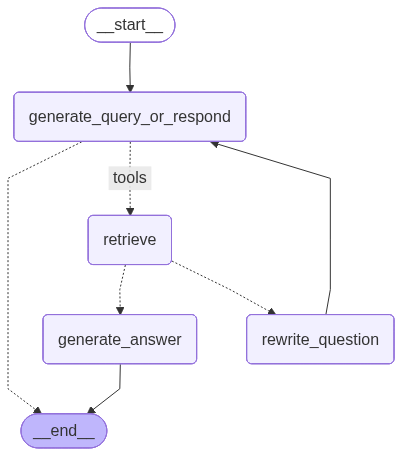

In [25]:
graph

In [26]:
for chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            }
        ]
    }
):
    for node, update in chunk.items():
        print("Update from node", node)
        update["messages"][-1].pretty_print()
        print("\n\n")

Update from node generate_query_or_respond
================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (0c82e275-416d-4be8-bdc4-0a782b58b542)
 Call ID: 0c82e275-416d-4be8-bdc4-0a782b58b542
  Args:
    query: Lilian Weng reward hacking types



Update from node retrieve
================================= Tool Message =================================
Name: retrieve_blog_posts

Citation#
Cited as:

Weng, Lilian. “Reward Hacking in Reinforcement Learning”. Lil’Log (Nov 2024). https://lilianweng.github.io/posts/2024-11-28-reward-hacking/.

Lil'Log

















|






Posts




Archive




Search




Tags




FAQ









      Reward Hacking in Reinforcement Learning
    
Date: November 28, 2024  |  Estimated Reading Time: 37 min  |  Author: Lilian Weng

author  = "Weng, Lilian",
  journal = "lilianweng.github.io",
  year    = "2024",
  month   = "Nov",
  url     = "https://lilianweng.github.io/posts/2024-11-28-reward-hacking/"
}
R